### MSW Zápočtová úloha

In [20]:
import numpy as np
import matplotlib.pyplot as pyp
from scipy.integrate import solve_ivp
from PIL import Image 

### Úloha 1: Lineární a nelineární oscilátory

*A)Lineární oscilátor(torzni kyvadlo)*

*B) Nelineární oscilátor (Rayleighův oscilátor)*

### A)Lineární oscilátor(torzni kyvadlo)

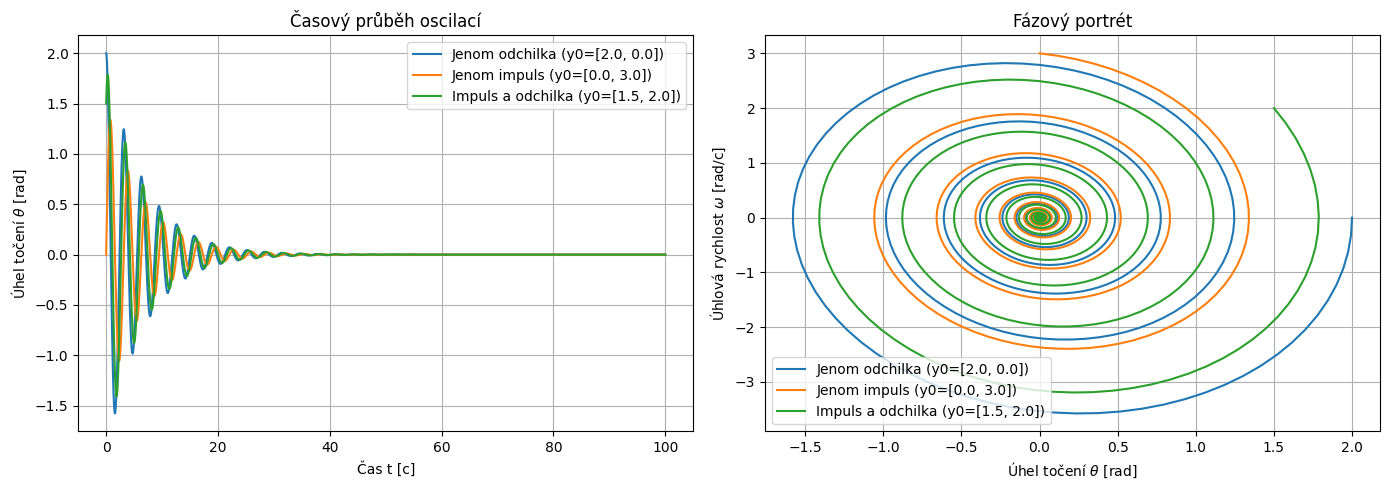

In [26]:
def torzni_kyvadlo (t, y, I, c, k):
    theta, omega = y 
    dtheta_dt = omega
    domega_dt = -(c/I) * omega - (k/I) * theta
    return [dtheta_dt, domega_dt]

I = 0.5
k = 2.0
c = 0.15


t_span = (0, 100)                       #casove rozmezi
t_eval = np.linspace(0, 100, 2500)      # casove body pro graf

initial_conditions = {
    'Jenom odchilka (y0=[2.0, 0.0])': [2.0, 0.0],
    'Jenom impuls (y0=[0.0, 3.0])': [0.0, 3.0],
    'Impuls a odchilka (y0=[1.5, 2.0])': [1.5, 2.0]
}

fig, (ax1, ax2) = pyp.subplots(1, 2, figsize = (14, 5))

for label, y0 in initial_conditions.items():
    sol = solve_ivp(torzni_kyvadlo, t_span, y0, args=(I, c, k), t_eval=t_eval)
    ax1.plot(sol.t, sol.y[0], label=label)
    ax2.plot(sol.y[0], sol.y[1], label=label)

ax1.set_title('Časový průběh oscilací')
ax1.set_xlabel ('Čas t [c]')
ax1.set_ylabel ('Úhel točení $\\theta$ [rad]')
ax1.grid(True)
ax1.legend()

ax2.set_title('Fázový portrét')
ax2.set_xlabel('Úhel točení $\\theta$ [rad]')
ax2.set_ylabel ('Úhlová rychlost $\\omega$ [rad/c]')
ax2.grid(True)
ax2.legend()

pyp.tight_layout()
pyp.show()

### A)Lineární oscilátor(torzni kyvadlo)

1.a) *Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?*

   *Slabé tlumení*: Systém vykonává opakované, postupně zanikající kmitavé pohyby kolem rovnovážné polohy. Na fázovém portrétu se trajektorie stáčí do spirály směřující k počátku (0,0).

   *Kritické tlumení*: Systém se vrátí do rovnovážné polohy v nejkratším možném čase. Na fázovém portrétu je příma cesta do středu.
   
   *Silné tlumení*: Odpor prostředí je příliš velký. Systém se vrací k nule velmi pomalu, bez oscilací.
   
2.a) *Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo kvalitativně ostrý?*

   Pokud se pohybujeme uvnitř režimu slabého nebo silného tlumení, změna o několik procent: perioda se nepatrně změní nebo křivka klesne o něco rychleji/pomaleji.
   
   Samotná hranice kritického tlumení je kvalitativně ostrá. Je matematicky definována přesnou rovností diskriminantu charakteristické rovnice (*c^2 = 4Ik*). Kdyz přesnou hodnotu překročíme, kořeny se změní z komplexně sdružených na čistě reálné, což radikálně mění podstatu matematického řešení (přechod z harmonických funkcí sinus/cosinus na čistou exponenciálu).

3.a) *Jaký mechanismus vede k rezonanci u buzeného kmitání?*

   K rezonanci dochází, když se frekvence externí budicí síly (harmonického buzení) přiblíží vlastní frekvenci oscilátoru (*$\omega \approx \omega_0$*). V takovém případě vnější síla dodává energii do systému přesně ve fázi s jeho přirozeným pohybem, což vede k dramatickému nárůstu amplitudy kmitů.

   Z mých grafů pro časový interval *$t \in \langle0,100\rangle$* je jasně , že volba počátečních podmínek ovlivňuje pouze přechodový jev na začátku simulace.  Na fázovém portrétu začíná každá trajektorie v jiném bodě, pak z dlouhodobého hlediska jsou všechny tři linie přitaženy do jediného stabilního bodu — počátku souřadnic *$(0,0)$*, což je stabilní ohnisko (atraktor). V čase *$t > 40\,\text{s}$* kmitání zcela vymizí.
   
4.a) *Dá se problém řešit pomocí symbolické matematiky? Jak?*

   Ano. Jedná se o lineární diferenciální rovnici s konstantními koeficienty, lze ji analyticky vyřešit přesně. V Pythonu k tomu můžeme použít knihovnu **sympy** a její funkci **dsolve()**, která nám poskytne obecné analytické řešení ve tvaru vzorce pro *$\theta(t)$* v závislosti na zadaných počátečních podmínkách.  

### B) Nelineární oscilátor (Rayleighův oscilátor)

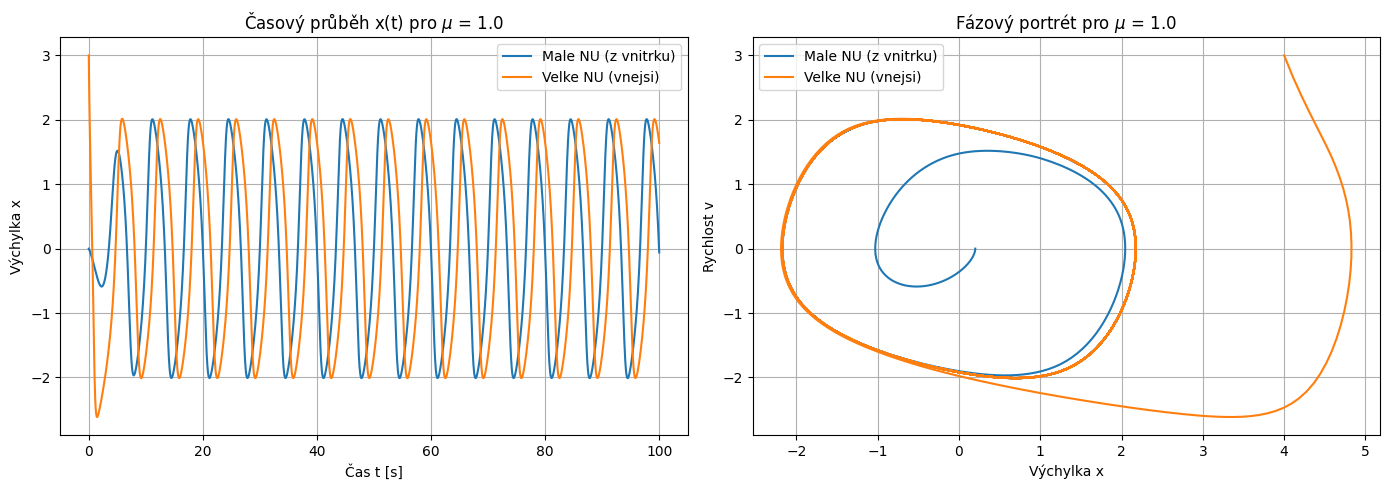

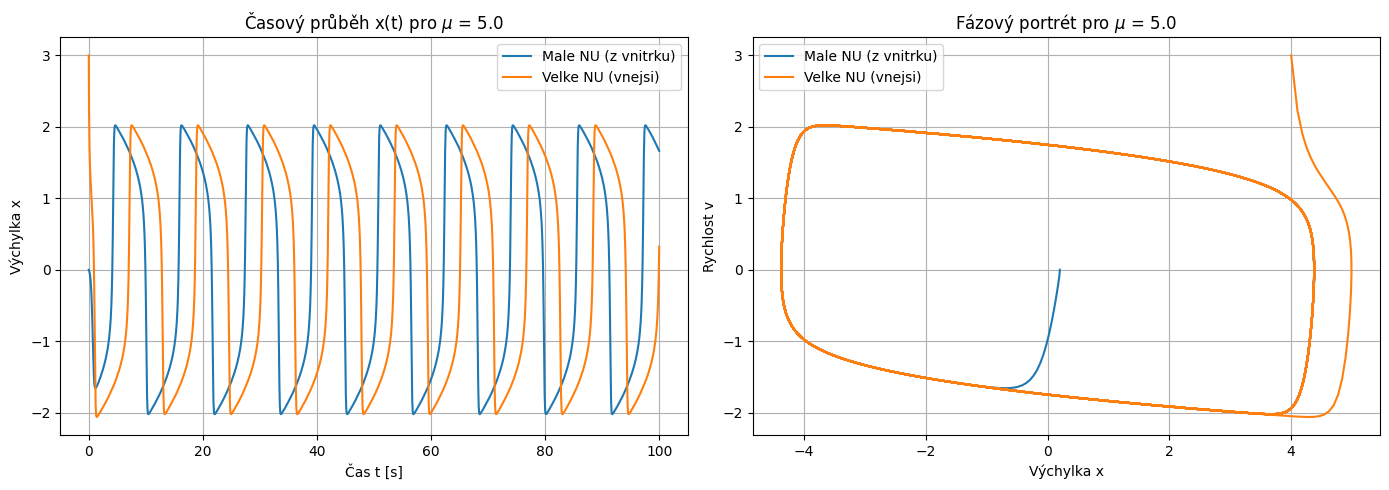

In [15]:
def rayleigh_oscillator(t,y,mu):
    x, v = y
    dx_dt = v
    dv_dt = mu * (1-(1/3) * v**2) * v - x
    return [dx_dt, dv_dt]

t_span = (0,100)
t_eval = np.linspace(0, 100, 2500)

initial_conditions = [
    ([0.2, 0.0], 'Male NU (z vnitrku)'),
    ([4.0, 3.0], 'Velke NU (vnejsi)')
]

for mu in [1.0, 5.0]:
    fig, (ax1, ax2) = pyp.subplots(1, 2, figsize=(14,5))

    for y0, label in initial_conditions:
        sol = solve_ivp(rayleigh_oscillator, t_span, y0, args=[mu], t_eval=t_eval)
        ax1.plot(sol.t, sol.y[1], label=label)
        ax2.plot(sol.y[0], sol.y[1], label=label)

    ax1.set_title(f'Časový průběh x(t) pro $\\mu$ = {mu}')
    ax1.set_xlabel('Čas t [s]')
    ax1.set_ylabel('Výchylka x')
    ax1.grid(True)
    ax1.legend()

    ax2.set_title(f'Fázový portrét pro $\\mu$ = {mu}')
    ax2.set_xlabel('Výchylka x')
    ax2.set_ylabel('Rychlost v')
    ax2.grid(True)
    ax2.legend()
    
    pyp.tight_layout()
    pyp.show()

### B) Nelineární oscilátor (Rayleighův oscilátor)

1.b) *Jak se mění tvar limitního cyklu při přechodu z mu=1 na mu=5?*

Při nízké nelinearitě ($mu = 1.0$) je limitní cyklus na fázovém portrétu hladký a svým tvarem se blíží elipse. Časový průběh $x(t)$ je v tomto režimu téměř harmonický (hladké sinusové vlny).  

S rostoucím parametrem nelinearity (na $mu = 5.0$) se limitní cyklus výrazně deformuje a získává ostrý, téměř pravoúhlý tvar. Časový průběh $x(t)$ ztrácí svou hladkost a mění se na tzv. relaxační kmity, které připomínají pilovitý průběh.  

2.b) *Proč při velkém mu vznikají rychlé skoky a pomalé fáze?*

Tento jev je způsoben silnou nelinearitou v tlumícím členu. Když je rychlost malá, tlumící člen působí jako "negativní tření" (dodává energii), což vede k pomalému budování amplitudy podél pozvolných větví atraktoru (pomalá fáze). Jakmile však systém dosáhne kritické meze, nelineární síly jej bleskově přetíží, což způsobí extrémně rychlý přechod do opačného stavu (rychlý skok), kde se proces opakuje.  
        
3.b) *Jaký je vliv počátečních podmínek na konečné chování? Existuje v modelu více atraktorů?*

Počáteční podmínky nemají na konečné chování systému žádný vliv. Z grafů je jasně vidět, že trajektorie startující zevnitř cyklu (malé NU) i trajektorie startující daleko zvenčí (velké NU) jsou po odeznění krátkého přechodového jevu přitaženy na úplně stejnou dráhu. V modelu existuje pouze jeden stabilní atraktor, kterým je právě tento jednoznačný limitní cyklus (mezní cyklus). Počátek souřadnic $(0,0)$ je v tomto případě nestabilním ohniskem (repulzorem), který systém od sebe odpuzuje směrem k limitnímu cyklu.

### Úloha 2: Programová implementace SIR modelu

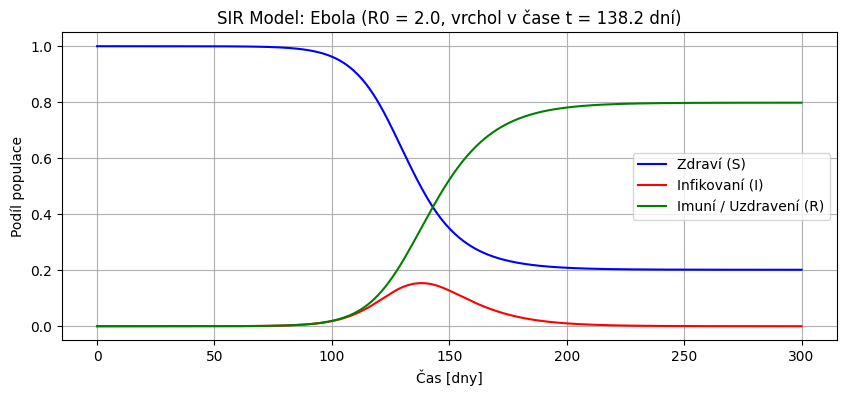

Statistiky pro Ebola
1. Vrchol epidemie: 138.2. den (nemocných je 15.4% populace)
2. Konec epidemie: přibližně 239.4. den
3. Výsledek: Celkem onemocnělo (R) = 79.83%, Zůstalo zdravých (S) = 20.16%



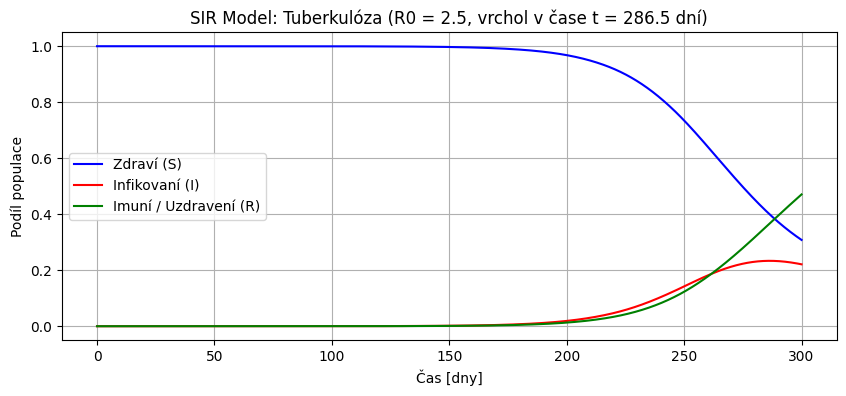

Statistiky pro Tuberkulóza
1. Vrchol epidemie: 286.5. den (nemocných je 23.4% populace)
2. Konec epidemie: přibližně 300.0. den
3. Výsledek: Celkem onemocnělo (R) = 47.07%, Zůstalo zdravých (S) = 30.82%



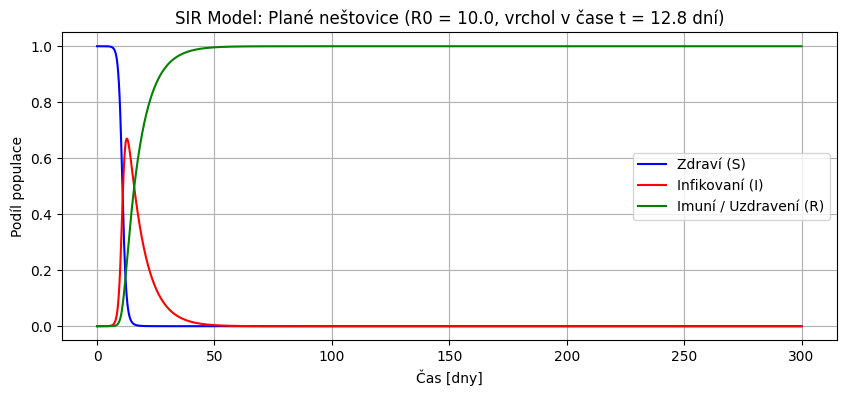

Statistiky pro Plané neštovice
1. Vrchol epidemie: 12.8. den (nemocných je 67.0% populace)
2. Konec epidemie: přibližně 59.6. den
3. Výsledek: Celkem onemocnělo (R) = 100.00%, Zůstalo zdravých (S) = 0.00%



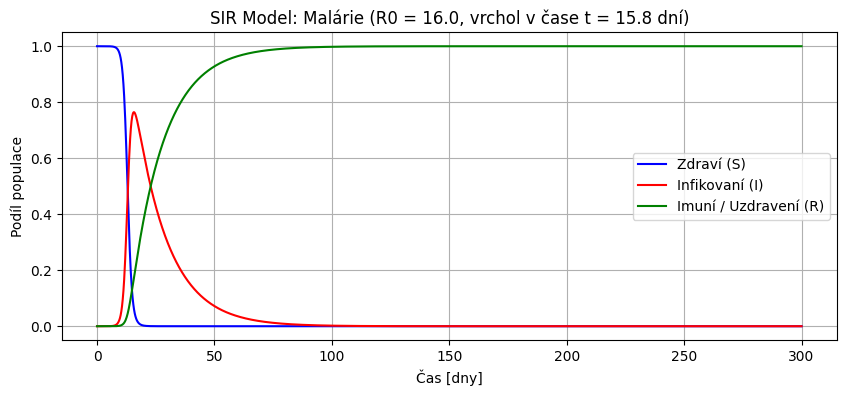

Statistiky pro Malárie
1. Vrchol epidemie: 15.8. den (nemocných je 76.4% populace)
2. Konec epidemie: přibližně 110.0. den
3. Výsledek: Celkem onemocnělo (R) = 100.00%, Zůstalo zdravých (S) = 0.00%



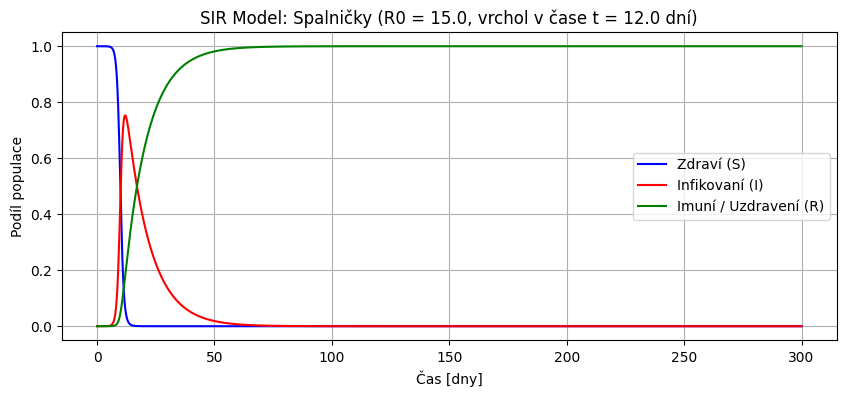

Statistiky pro Spalničky
1. Vrchol epidemie: 12.0. den (nemocných je 75.3% populace)
2. Konec epidemie: přibližně 79.2. den
3. Výsledek: Celkem onemocnělo (R) = 100.00%, Zůstalo zdravých (S) = 0.00%



In [17]:
def sir_model(t, y, beta, gamma):
    S, I, R = y
    dS_dt = -beta *S*I
    dI_dt = beta * S * I - gamma * I
    dR_dt = gamma * I
    return [dS_dt, dI_dt, dR_dt]

t_span = (0, 300)
t_eval = np.linspace(0, 300, 2000)

y0 = [1.0 - 1e-6, 1e-6, 0.0]

diseases = {
    'Ebola': (2.0, 10),
    'Tuberkulóza': (2.5, 30),        
    'Plané neštovice': (10.0, 7),
    'Malárie': (16.0, 14),           
    'Spalničky': (15.0, 10)
}

for name, (R0, duration) in diseases.items():
    gamma = 1.0/duration
    beta = R0 * gamma

    sol = solve_ivp(sir_model, t_span, y0, args=(beta, gamma), t_eval=t_eval)

    pyp.figure(figsize=(10, 4))
    pyp.plot(sol.t, sol.y[0], 'b-', label='Zdraví (S)')
    pyp.plot(sol.t, sol.y[1], 'r-', label='Infikovaní (I)')
    pyp.plot(sol.t, sol.y[2], 'g-', label='Imuní / Uzdravení (R)')

    idx_peak = np.argmax(sol.y[1])
    t_peak = sol.t[idx_peak]
    I_peak = sol.y[1][idx_peak]

    S_end = sol.y[0][-1]
    R_end = sol.y[2][-1]

    pyp.title(f'SIR Model: {name} (R0 = {R0}, vrchol v čase t = {t_peak:.1f} dní)')
    pyp.xlabel('Čas [dny]')
    pyp.ylabel('Podíl populace')
    pyp.grid(True)
    pyp.legend()
    pyp.show()


    print(f"Statistiky pro {name}")
    print(f"1. Vrchol epidemie: {t_peak:.1f}. den (nemocných je {I_peak*100:.1f}% populace)")

    end_days = sol.t[sol.y[1] < 0.001]
    t_end = end_days[end_days > t_peak][0] if len(end_days[end_days > t_peak]) > 0 else 300
    print(f"2. Konec epidemie: přibližně {t_end:.1f}. den")
    print(f"3. Výsledek: Celkem onemocnělo (R) = {R_end*100:.2f}%, Zůstalo zdravých (S) = {S_end*100:.2f}%\n")

### Úloha 2: Vyhodnocení výsledků SIR modelu


### 1. Ebola ($R_0 = 2.0$, trvání nemoci: 10 dní)
* **Vrchol epidemie:** Nastane **138.2. den** od začátku šíření. V tomto okamžiku bude akutně nakaženo **15.4 %** populace.
* **Trvání epidemie:** Epidemie potrvá přibližně **239.4 dní**, kdy podíl aktivně nemocných klesne pod kritickou hranici 0.1 %.
* **Konečný výsledek:** Celkově v populaci onemocní (**79.83 %**) jedinců (skupina R). Infekci se zcela vyhne a zdravých zůstane (**20.16 %**) populace (skupina S).

### 2. Tuberkulóza ($R_0 = 2.5$, trvání nemoci: 30 dní)
* **Vrchol epidemie:** Vzhledem k dlouhé době trvání nemoci se epidemie rozvíjí velmi pomalu. Vrchol nastane až **286.5. den**, kdy podíl nakažených dosáhne **23.4 %**.
* **Trvání epidemie:** Epidemie přesáhne sledovaný interval 300 dní. Pokles aktivních případů nastane až hluboko po 300. dni.
* **Konečný výsledek:** Do 300. dne stihne onemocnět **47.07 %** populace. Zcela zdravých v tento moment zůstává **30.82 %** (zbytek populace je stále aktivně nemocný).

### 3. Plané neštovice ($R_0 = 10.0$, trvání nemoci: 7 dní)
* **Vrchol epidemie:** Velmi vysoké $R_0$ způsobuje bleskový nástup. Vrchol nastane již **12.8. den**, přičemž v jeden moment bude nakaženo obrovské množství lidí — **67.0 %** populace.
* **Trvání epidemie:** Epidemie má sice agresivní, ale krátký průběh. Skončí přibližně **59.6. den**.
* **Konečný výsledek:** Kvůli extrémní nakažlivosti onemocní nakonec celá populace — **100.00 %** (skupina R). Nezůstane nikdo zdravý (**0.00 %** ve skupina S).

### 4. Malárie ($R_0 = 16.0$, trvání nemoci: 14 dní)
* **Vrchol epidemie:** Vrchol nastane velmi brzy, konkrétně **15.8. den**. Na vrcholu bude najednou nemocných **76.4 %** populace.
* **Trvání epidemie:** Aktivní vlna epidemie potrvá přibližně **110.0 dní**, než se situace zcela uklidní.
* **Konečný výsledek:** Podobně jako u neštovic, v důsledku vysokého reprodukčního čísla nakonec onemocní celých **100.00 %** jedinců. Podíl zdravých, kteří se nenakazili, je **0.00 %**.

### 5. Spalničky ($R_0 = 15.0$, trvání nemoci: 10 dní)
* **Vrchol epidemie:** Spalničky vykážou nejrychlejší nástup ze všech sledovaných chorob. Vrchol nastane už **12.0. den**, kdy bude nemocných **75.3 %** populace.
* **Trvání epidemie:** Epidemie odezní přibližně **79.2. den**.
* **Konečný výsledek:** Výsledek potvrdí stoprocentní zasažení populace. Celkem onemocní **100.00 %** jedinců, imunní vůči nákaze nezůstane nikdo (**0.00 %** zdravých).


### Shrnutí:
Z porovnání modelů je jasně , že **základní reprodukční číslo ($R_0$) zásadně určuje dynamiku epidemie**. Nemoci s nízkým $R_0$ (Ebola, Tuberkulóza) mají pozvolný nástup, nižší vrchol a významná část populace se vůněm nenakazí (kolektivní imunita zapůsobí dříve). Naopak nemoci s vysokým $R_0$ $\ge 10$ (Spalničky, Plané neštovice, Malárie) vyvolávají explozivní vlny s extrémně vysokým vrcholem v řádu dnů a nakonec infikují celou populaci bez výjimky.

### Úloha 3: Vytvoření vlastního modelu (Anizotropní filtrace obrazu (Manga) pomocí PDE (Model Perona-Malik))

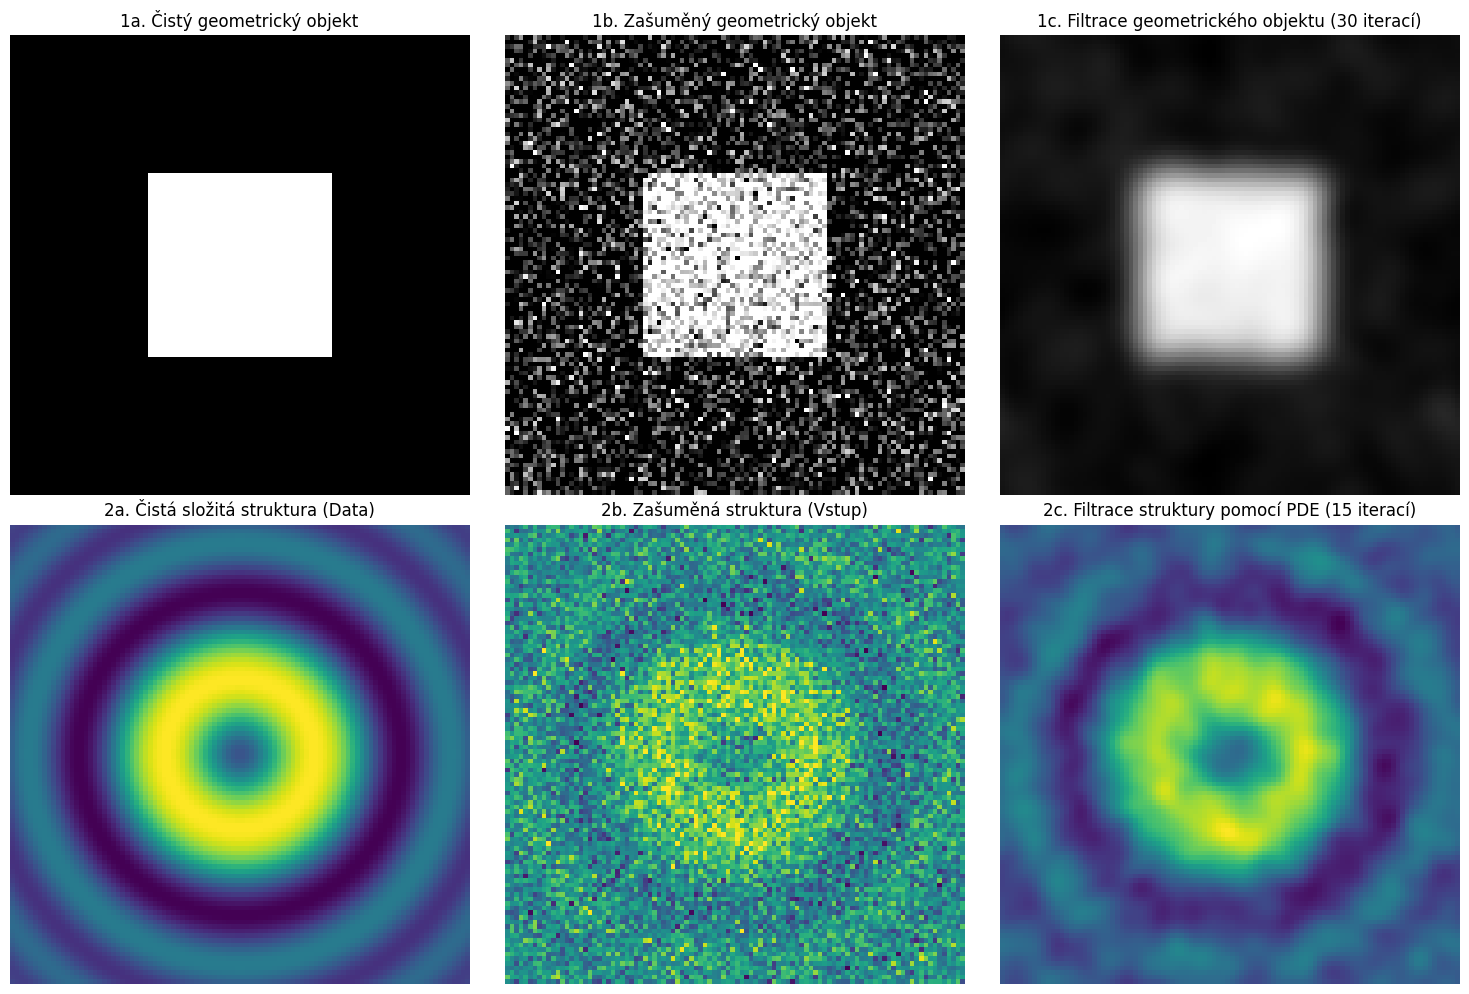

In [21]:

N = 100
image_clean = np.zeros((N,N))
image_clean [30:70, 30:70] = 1.0

np.random.seed(42)
noise = np.random.normal(0, 0.4, (N,N))
image_noisy = np.clip(image_clean + noise, 0, 1)

dt = 0.2
iterations = 30
I = image_noisy.copy()

for _ in range(iterations):
    laplacian = (
        np.roll(I, 1, axis=0) + np.roll(I, -1, axis=0) +
        np.roll(I, 1, axis=1) + np.roll(I, -1, axis=1) - 4 * I
    )
    I += dt * laplacian 

x = np.linspace(-3, 3, N)
y = np.linspace(-3, 3, N)
X, Y = np.meshgrid(x, y)
image_real_clean = np.sin(X**2 + Y**2) / (X**2 + Y**2 + 0.5)

noise_real = np.random.normal(0, 0.3, (N, N))
image_real_noisy = np.clip(image_real_clean + noise_real, -1, 1)

I_real = image_real_noisy.copy()
dt_real = 0.15
iterations_real = 15

for _ in range(iterations_real):
    laplacian_real = (
        np.roll(I_real, 1, axis=0) + np.roll(I_real, -1, axis=0) +
        np.roll(I_real, 1, axis=1) + np.roll(I_real, -1, axis=1) - 4 * I_real
    )
    I_real += dt_real * laplacian_real


fig, axes = pyp.subplots(2, 3, figsize=(15, 10))


axes[0, 0].imshow(image_clean, cmap='gray')
axes[0, 0].set_title('1a. Čistý geometrický objekt')
axes[0, 0].axis('off')

axes[0, 1].imshow(image_noisy, cmap='gray')
axes[0, 1].set_title('1b. Zašuměný geometrický objekt')
axes[0, 1].axis('off')

axes[0, 2].imshow(I, cmap='gray')  
axes[0, 2].set_title(f'1c. Filtrace geometrického objektu ({iterations} iterací)')
axes[0, 2].axis('off')


axes[1, 0].imshow(image_real_clean, cmap='viridis')
axes[1, 0].set_title('2a. Čistá složitá struktura (Data)')
axes[1, 0].axis('off') 

axes[1, 1].imshow(image_real_noisy, cmap='viridis')
axes[1, 1].set_title('2b. Zašuměná struktura (Vstup)')
axes[1, 1].axis('off')

axes[1, 2].imshow(I_real, cmap='viridis')
axes[1, 2].set_title(f'2c. Filtrace struktury pomocí PDE ({iterations_real} iterací)')
axes[1, 2].axis('off')

pyp.tight_layout()
pyp.show()

Ostrý výsledný obrázek byl uložen jako 'manga_vysledek_ostry.png'!


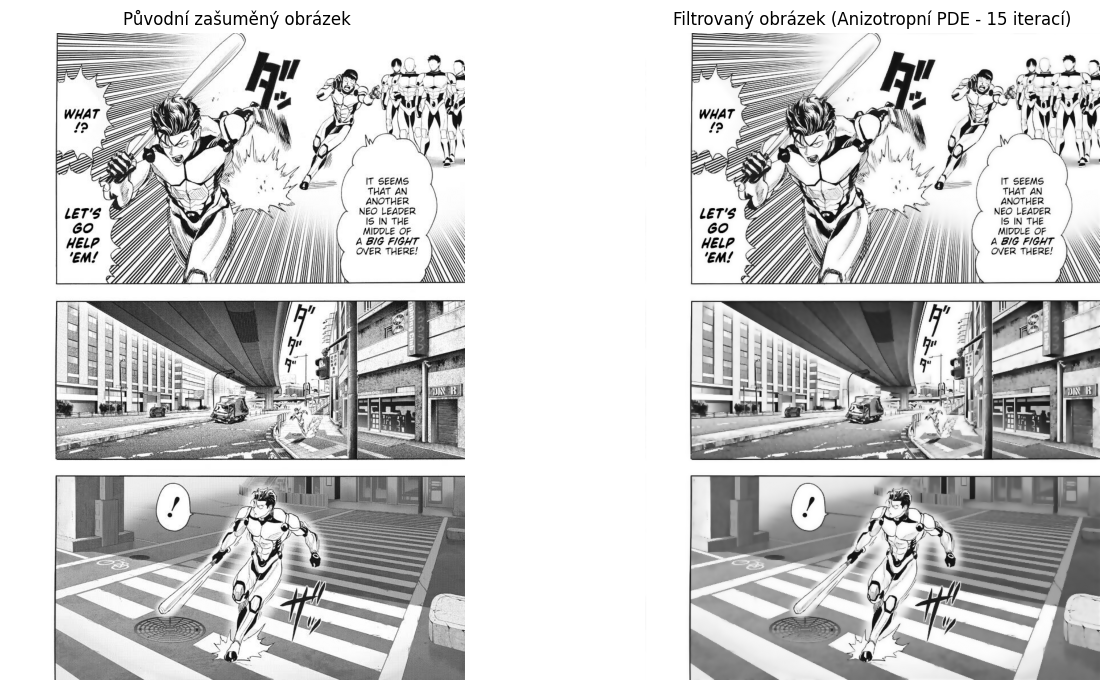

In [25]:

nazev_souboru = 'manga.jpg' 

try:
    img = Image.open(nazev_souboru).convert('L')
    image_input = np.array(img) / 255.0
    
    
    dt = 0.2
    iterations = 15
    K = 0.05  
    I = image_input.copy()

    for _ in range(iterations):
        
        deltaN = np.roll(I, -1, axis=0) - I
        deltaS = np.roll(I, 1, axis=0) - I
        deltaE = np.roll(I, -1, axis=1) - I
        deltaW = np.roll(I, 1, axis=1) - I
        
        
        cN = 1.0 / (1.0 + (deltaN / K)**2)
        cS = 1.0 / (1.0 + (deltaS / K)**2)
        cE = 1.0 / (1.0 + (deltaE / K)**2)
        cW = 1.0 / (1.0 + (deltaW / K)**2)
        
        
        I += dt * (cN * deltaN + cS * deltaS + cE * deltaE + cW * deltaW)

    
    fig, (ax1, ax2) = pyp.subplots(1, 2, figsize=(14, 7))

    ax1.imshow(image_input, cmap='gray')
    ax1.set_title('Původní zašuměný obrázek')
    ax1.axis('off')

    ax2.imshow(I, cmap='gray')
    ax2.set_title(f'Filtrovaný obrázek (Anizotropní PDE - {iterations} iterací)')
    ax2.axis('off')

    pyp.tight_layout()
    

    pyp.savefig('manga_vysledek_ostry.png', dpi=300, bbox_inches='tight')
    print("Ostrý výsledný obrázek byl uložen jako 'manga_vysledek_ostry.png'!")
    
    pyp.show()

except FileNotFoundError:
    print(f"Chyba: Soubor '{nazev_souboru}' nebyl nalezen ve složce!")

## Úloha 3: Vlastní model – Anizotropní filtrace obrazu (Manga) pomocí PDE (Model Perona-Malik)

Pro třetí úlohu jsem zvolila pokročilou aplikaci parciálních diferenciálních rovnic v oblasti počítačového vidění a digitálního zpracování obrazu. Model je demonstrován na reálných datech — stránce z mangy, kde je klíčové odstranit digitální šum a artefakty komprese, ale zároveň **zachovat dokonale ostré hrany** (kresbu a text).

### Matematický princip (Model Perona-Malik):
Obyčejná (izotropní) rovnice vedení tepla vyhlazuje obraz rovnoměrně do všech směrů, což způsobuje nežádoucí rozmazání (tzv. "blur" efekt). Abychom tomu zabránili, použijeme **anizotropní difúzi**, kde je difuzní koeficient $c$ nelineární funkcí velikosti gradientu jasu:

$$\frac{\partial I}{\partial t} = \text{div}\Big( c\big(\|\nabla I\|\big) \cdot \nabla I \Big)$$

V tomto modelu byla použita konkrétní schválená funkce vodivosti Perona-Malik:

$$c\big(\|\nabla I\|\big) = \frac{1}{1 + \left(\frac{\|\nabla I\|}{K}\right)^2}$$

* **Uvnitř homogenních oblastí** (např. čistě bílé pozadí): Gradient $\|\nabla I\|$ je blízký nule, koeficient $c \approx 1$, a rovnice se chová jako klasická difúze — efektivně odstraňuje drobný šum.
* **Na hranách objektů** (černé obrysy postav, text): Gradient $\|\nabla I\|$ je extrémně vysoký, zlomek ve jmenovateli roste a koeficient vodivosti prudce klesá k nule ($c \approx 0$). Difúzní proces se v těchto místech **zastaví**, díky čemuž zůstávají hrany dokonale ostré a nerozmazané.

### Interpretace výsledků:
* **Parametry simulace:** Numerické řešení využívá časový krok $\Delta t = 0.2$ a parametr citlivosti hran $K = 0.05$. Celkem bylo provedeno 15 iterací explicitní metody konečných diferencí.
* **Analýza výsledku:** Jak je vidět na porovnání grafů, anizotropní filtr úspěšně vyčistil jemné šedé body a nečistoty z bílého pozadí stránky. Zároveň však — na rozdíl od standardního filtru — jemné čáry vlasů, kontury svalů a text v bublinách zůstaly kontrastní a čitelné.

### Závěr pro obor "Matematika ve firmách a veřejné správě":
Tento model názorně ukazuje, jak lze teoretické koncepty parciálních derivací, gradientu a divergence využít k budování sofistikovaných algoritmů. V komerční praxi firem se tento matematický aparát využívá například při čištění naskenovaných dokumentů, rozpoznávání textu (OCR), zpracování satelitních snímků nebo filtráži medicínských dat (rentgen, MRI).